In [1]:
import scanpy as sc
import scvi
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
adata = sc.read_h5ad('STH.h5ad')

In [3]:
adata.obs ## adata obs for cell ids usually

,roi,disease_ontology_term_id,self_reported_ethnicity_ontology_term_id,assay_ontology_term_id,sex_ontology_term_id,development_stage_ontology_term_id,donor_id,suspension_type,dissection,fraction_mitochondrial,...,cell_type_ontology_term_id,Region,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
CellID,,,,,,,,,,,,,,,,,,,,,
10X361_1:TCCTCCCAGGCTGAAC,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.024923,...,CL:0000236,thalamus,B cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,HecEAK~dBP
10X361_2:CCAATTTGTGGCTTAT,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.038226,...,CL:0000084,thalamus,T cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,C3$)##=_#d
10X385_6:TGAACGTAGATACGAT,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.009259,...,CL:0000084,thalamus,T cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,29-year-old stage,g5HZ=Z$Dc}
10X361_2:CCAATGACACTGTCGG,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.071429,...,CL:0000084,thalamus,T cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,EeDu&#`M-K
10X385_5:GGGTATTGTTCAGCGC,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.009569,...,CL:0000084,thalamus,T cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,29-year-old stage,MLi>p)1$&P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X361_1:ACGTACACAATCCTTT,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000000,...,CL:0000128,thalamus,oligodendrocyte,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,6sU~?clMbQ
10X361_2:CTCAGAATCCACTTTA,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000000,...,CL:0000128,thalamus,oligodendrocyte,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,d;Az=J~=bP
10X361_2:CAGATTGGTTCAAAGA,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000545,...,CL:0000128,thalamus,oligodendrocyte,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,7CA!B{<ebF


In [3]:
adata.var ## which is information about the genes

,Biotype,Chromosome,End,Gene,Start,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000251309,n/a,chr4,102036903,AP002075.1,101976894,False,ENSG00000251309,NCBITaxon:9606,gene,603,lncRNA
ENSG00000197943,n/a,chr16,81962685,PLCG2,81739097,False,PLCG2,NCBITaxon:9606,gene,1305,protein_coding
ENSG00000115232,n/a,chr2,181538940,ITGA4,181457202,False,ITGA4,NCBITaxon:9606,gene,1144,protein_coding
ENSG00000153898,n/a,chr1,84997113,MCOLN2,84925583,False,MCOLN2,NCBITaxon:9606,gene,1719,protein_coding
ENSG00000136573,n/a,chr8,11564599,BLK,11486894,False,BLK,NCBITaxon:9606,gene,1557,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000127507,n/a,chr19,14778560,ADGRE2,14732392,False,ADGRE2,NCBITaxon:9606,gene,2193,protein_coding
ENSG00000198756,n/a,chr1,184037729,COLGALT2,183929854,False,COLGALT2,NCBITaxon:9606,gene,2412,protein_coding
ENSG00000016602,n/a,chr1,86580754,CLCA4,86547078,False,CLCA4,NCBITaxon:9606,gene,1846,protein_coding
ENSG00000019144,n/a,chr11,118658031,PHLDB1,118606440,False,PHLDB1,NCBITaxon:9606,gene,1714,protein_coding


In [4]:
adata.X.shape # sprase matrix of genes by features

(20162, 58232)

### First start with doublet removal

In [ ]:
## Doublet removal on individual samples and then move towards integration

In [6]:
sc.pp.filter_genes(adata, min_cells=10) ## doing only genes in 10 cells

In [7]:
sc.pp.highly_variable_genes(adata, n_top_genes = 3000, subset=True, flavor='seurat_v3')

In [8]:
scvi.model.SCVI.setup_anndata(adata)
vae = scvi.model.SCVI(adata)
vae.train(accelerator="mps", devices=1)#, num_workers=9)
 # train a modell to predict doubles

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usual. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and tr

Training:   0%|          | 0/397 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=397` reached.


In [9]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

INFO     Creating doublets, preparing SOLO model.                                                                  


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-pa

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.129. Signaling Trainer to stop.


In [ ]:
solo.predict() ## higher the value = more true

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet
10X361_1:TCCTCCCAGGCTGAAC,0.007592,0.992408
10X361_2:CCAATTTGTGGCTTAT,0.169335,0.830665
10X385_6:TGAACGTAGATACGAT,0.000398,0.999602
10X361_2:CCAATGACACTGTCGG,0.006552,0.993448
10X385_5:GGGTATTGTTCAGCGC,0.000002,0.999998
...,...,...
10X361_1:ACGTACACAATCCTTT,0.006199,0.993802
10X361_2:CTCAGAATCCACTTTA,0.954635,0.045365
10X361_2:CAGATTGGTTCAAAGA,0.000006,0.999994
10X361_1:TGGCGTGTCCATAGAC,0.019592,0.980408


In [11]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)

df

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet,prediction
10X361_1:TCCTCCCAGGCTGAAC,0.007592,0.992408,singlet
10X361_2:CCAATTTGTGGCTTAT,0.169335,0.830665,singlet
10X385_6:TGAACGTAGATACGAT,0.000398,0.999602,singlet
10X361_2:CCAATGACACTGTCGG,0.006552,0.993448,singlet
10X385_5:GGGTATTGTTCAGCGC,0.000002,0.999998,singlet
...,...,...,...
10X361_1:ACGTACACAATCCTTT,0.006199,0.993802,singlet
10X361_2:CTCAGAATCCACTTTA,0.954635,0.045365,doublet
10X361_2:CAGATTGGTTCAAAGA,0.000006,0.999994,singlet
10X361_1:TGGCGTGTCCATAGAC,0.019592,0.980408,singlet


In [ ]:
df.groupby('prediction').count() # ~ says roughly 20% of data is a doublet

,doublet,singlet
prediction,,
doublet,1831,1831
singlet,18331,18331


In [14]:
df['dif'] = df.doublet - df.singlet
df

,doublet,singlet,prediction,dif
10X361_1:TCCTCCCAGGCTGAAC,0.007592,0.992408,singlet,-0.984816
10X361_2:CCAATTTGTGGCTTAT,0.169335,0.830665,singlet,-0.661330
10X385_6:TGAACGTAGATACGAT,0.000398,0.999602,singlet,-0.999205
10X361_2:CCAATGACACTGTCGG,0.006552,0.993448,singlet,-0.986897
10X385_5:GGGTATTGTTCAGCGC,0.000002,0.999998,singlet,-0.999997
...,...,...,...,...
10X361_1:ACGTACACAATCCTTT,0.006199,0.993802,singlet,-0.987603
10X361_2:CTCAGAATCCACTTTA,0.954635,0.045365,doublet,0.909270
10X361_2:CAGATTGGTTCAAAGA,0.000006,0.999994,singlet,-0.999987
10X361_1:TGGCGTGTCCATAGAC,0.019592,0.980408,singlet,-0.960816


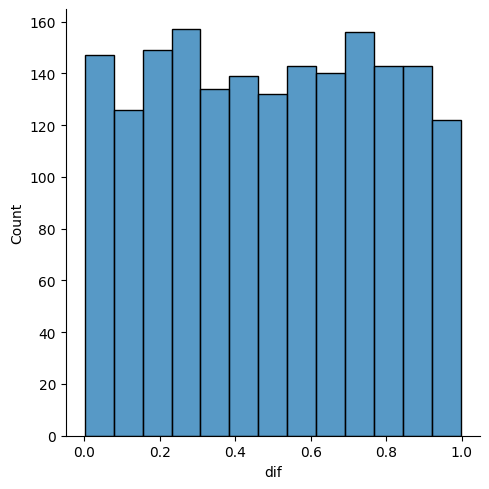

In [19]:
sns.displot(df[df.prediction == 'doublet'], x = 'dif')

In [ ]:
## here we can use an arbitrary selection of 0.8 to remove

In [21]:
doublets = df[(df.prediction == 'doublet') & (df.dif > 0.8)]
doublets

,doublet,singlet,prediction,dif
10X385_6:GATCGTAGTCAAAGAT,0.986246,0.013754,doublet,0.972491
10X361_2:ATGAGGGCAATACCTG,0.970617,0.029383,doublet,0.941234
10X361_2:AGTCATGAGATCGCTT,0.957124,0.042876,doublet,0.914247
10X361_1:ATTACCTAGGGCTAAC,0.952691,0.047309,doublet,0.905382
10X385_5:TAACACGCATCACGGC,0.998198,0.001802,doublet,0.996396
...,...,...,...,...
10X361_1:TTACAGGCACTAGGCC,0.969627,0.030373,doublet,0.939253
10X385_6:CCTCTAGCACTTCCTG,0.918461,0.081539,doublet,0.836923
10X385_5:CACTTCGTCTTACACT,0.987089,0.012911,doublet,0.974178
10X361_1:CCACTTGGTACTAACC,0.916511,0.083489,doublet,0.833021


In [23]:
## Reload adata to remove all doublets by matching barcodes
adata = sc.read_h5ad('STH.h5ad')

In [26]:
adata.obs['doublet'] = adata.obs.index.isin(doublets.index)

In [27]:
adata.obs

,roi,disease_ontology_term_id,self_reported_ethnicity_ontology_term_id,assay_ontology_term_id,sex_ontology_term_id,development_stage_ontology_term_id,donor_id,suspension_type,dissection,fraction_mitochondrial,...,Region,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,doublet
CellID,,,,,,,,,,,,,,,,,,,,,
10X361_1:TCCTCCCAGGCTGAAC,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.024923,...,thalamus,B cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,HecEAK~dBP,False
10X361_2:CCAATTTGTGGCTTAT,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.038226,...,thalamus,T cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,C3$)##=_#d,False
10X385_6:TGAACGTAGATACGAT,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.009259,...,thalamus,T cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,29-year-old stage,g5HZ=Z$Dc},False
10X361_2:CCAATGACACTGTCGG,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.071429,...,thalamus,T cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,EeDu&#`M-K,False
10X385_5:GGGTATTGTTCAGCGC,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.009569,...,thalamus,T cell,10x 3' v3,normal,male,subthalamic nucleus,unknown,29-year-old stage,MLi>p)1$&P,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X361_1:ACGTACACAATCCTTT,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000000,...,thalamus,oligodendrocyte,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,6sU~?clMbQ,False
10X361_2:CTCAGAATCCACTTTA,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000000,...,thalamus,oligodendrocyte,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,d;Az=J~=bP,True
10X361_2:CAGATTGGTTCAAAGA,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000545,...,thalamus,oligodendrocyte,10x 3' v3,normal,male,subthalamic nucleus,unknown,42-year-old stage,7CA!B{<ebF,False


In [ ]:
adata = adata[~adata.obs.doublet]
# keep everything that is false, where true is denoted as doublet

In [29]:
adata

View of AnnData object with n_obs × n_vars = 19811 × 58232
    obs: 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'is_primary_data', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'doublet'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_UMAP', 'X_tSNE'

In [30]:
## Saving progress before preprocessing
adata.write("STH_without_doublet.h5ad", compression="gzip")


## Preprocessing now!!

In [2]:
adata = sc.read_h5ad('STH_without_doublet.h5ad')

In [3]:
adata.var['mt'] =  adata.var['Gene'].str.startswith('MT-')
## say your adata.var is 0 columns wide, then replace ['Gene'] with var.index.str...

In [ ]:
## using a list of known ribosomal genes from the broad institute

In [4]:
ribo_genes = pd.read_table('KEGG_RIBOSOME.v2026.1.Hs.txt', skiprows=2, header = None)

In [5]:
adata.var['ribo'] = adata.var['Gene'].isin(ribo_genes[0].values)

In [6]:
## Now calculate the QC METRICS!
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)


In [7]:
## Now filtering out genes that we not in at least 3 cells
sc.pp.filter_genes(adata, min_cells=3)

In [8]:
adata.obs.sort_values('n_genes_by_counts')

,roi,disease_ontology_term_id,self_reported_ethnicity_ontology_term_id,assay_ontology_term_id,sex_ontology_term_id,development_stage_ontology_term_id,donor_id,suspension_type,dissection,fraction_mitochondrial,...,self_reported_ethnicity,development_stage,observation_joinid,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
CellID,,,,,,,,,,,,,,,,,,,,,
10X385_5:GAAGCGAAGTGAATAC,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000000,...,unknown,29-year-old stage,&SHbMA74t1,False,609,863.0,0.0,0.000000,23.0,2.665122
10X385_5:AGGGTCCGTGTCCACG,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.001140,...,unknown,29-year-old stage,*Jqf{vWt;h,False,629,875.0,1.0,0.114286,23.0,2.628571
10X385_5:CAGCGTGCAGGCACAA,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.001129,...,unknown,29-year-old stage,(+c|@VxE_F,False,632,883.0,1.0,0.113250,27.0,3.057758
10X385_5:ACGTCCTGTGTTGACT,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000000,...,unknown,29-year-old stage,0AT$HjweEl,False,642,899.0,0.0,0.000000,24.0,2.669633
10X385_5:GTTGCGGGTCGCTGCA,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000123,H19.30.002,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000000,...,unknown,29-year-old stage,fpe0{u4+y0,False,650,939.0,0.0,0.000000,20.0,2.129925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X361_1:CATTCATGTTGCACGC,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000697,...,unknown,42-year-old stage,tKnzG39?yl,False,9050,38574.0,27.0,0.069995,227.0,0.588479
10X361_2:ACGATGTTCTAAACGC,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.000439,...,unknown,42-year-old stage,Zd2UIs{L@G,False,9211,43074.0,19.0,0.044110,205.0,0.475925
10X361_1:GTATTTCCACACACTA,Human STH,PATO:0000461,unknown,EFO:0009922,PATO:0000384,HsapDv:0000136,H19.30.001,nucleus,Thalamus (THM) - Subthalamic nucleus and nearb...,0.001397,...,unknown,42-year-old stage,2BSZ`yzxjB,False,9246,43501.0,61.0,0.140227,193.0,0.443668


In [9]:
## then keep cells with AT LEAST only 700 genes
sc.pp.filter_cells(adata, min_genes=700)

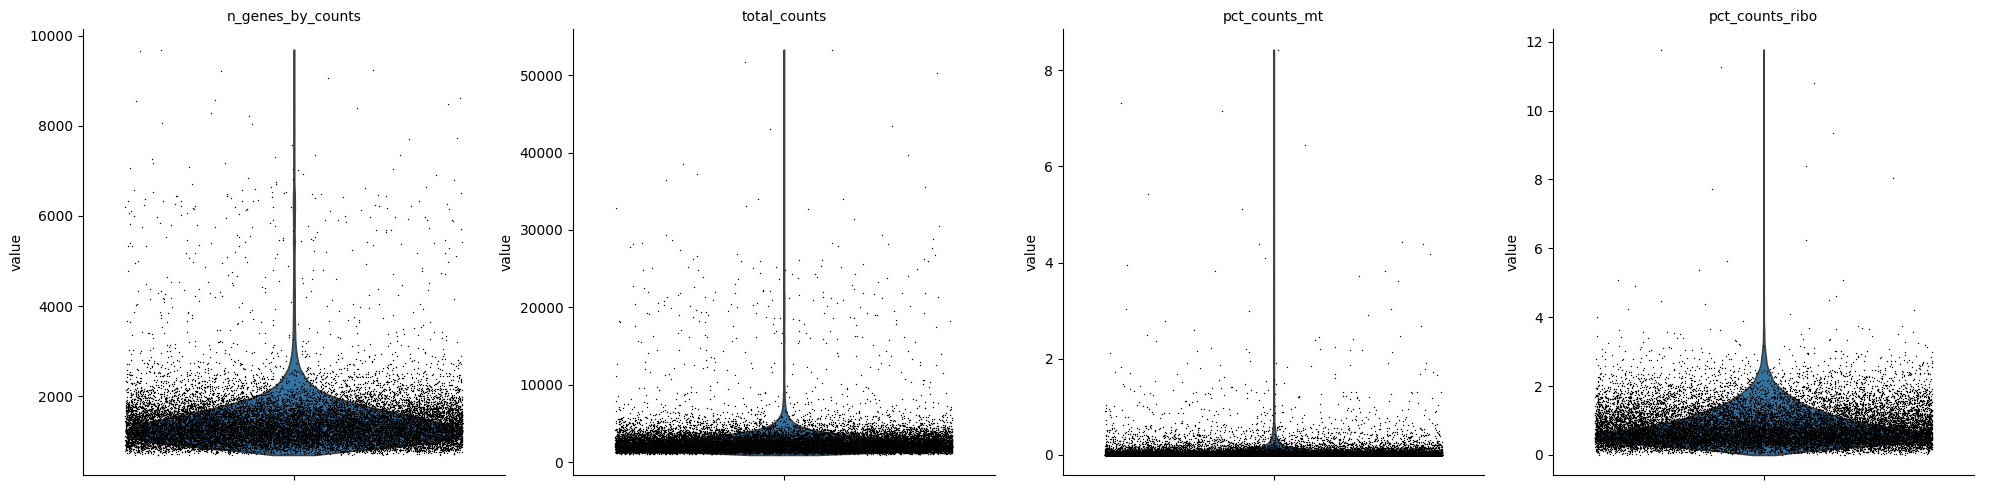

In [10]:
#### Now plotting qc metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'], 
             jitter=0.4, multi_panel=True)

In [12]:
## to be more objective, we will removal the top 2% of cells, keeping the other 98%
## so essentially removing the top 2% quartile


# upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)

## Or if we wanted to set an arbitrary value based off the violin plots, we could do upper_lim = 3000

In [11]:
upper_lim = 3500 ## setting an arbitrary value here

In [12]:
adata = adata[adata.obs.n_genes_by_counts < upper_lim] ## Adjusting for the genes here

In [13]:
adata = adata[adata.obs.pct_counts_ribo < 3] # Doing less than 3% ribosomal

In [14]:
adata = adata[adata.obs.pct_counts_mt < 6] # Removing cells with 6% mitochondrial or more

In [15]:
adata.layers["raw_counts"] = adata.X.copy()

/var/folders/9x/rm_064gx7k5bl4rpmwmghsv40000gn/T/ipykernel_29443/2164063776.py:1: ImplicitModificationWarning: Setting element `.layers['raw_counts']` of view, initializing view as actual.
  adata.layers["raw_counts"] = adata.X.copy()


In [16]:
adata

AnnData object with n_obs × n_vars = 19405 × 30383
    obs: 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'is_primary_data', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'n_cells_by_counts', 'mean

## Normalization!!

In [17]:
adata.X.sum(axis = 1)

matrix([[1185.],
        [2067.],
        [1622.],
        ...,
        [1830.],
        [2091.],
        [1936.]], shape=(19405, 1), dtype=float32)

In [18]:
sc.pp.normalize_total(adata, target_sum=1e4) # normalize all cells to 10,000 UMI via log based transformation

In [19]:
adata.X.sum(axis = 1)

matrix([[ 9999.999],
        [10000.   ],
        [10000.   ],
        ...,
        [10000.   ],
        [10000.001],
        [10000.001]], shape=(19405, 1), dtype=float32)

In [20]:
sc.pp.log1p(adata) # change to log counts via log based normalization

In [21]:
## Now save raw data
adata.raw = adata.copy()


### Clustering time!! 

In [22]:
## Make highly variable genes again
sc.pp.highly_variable_genes(adata, n_top_genes = 3000, subset=False)

In [23]:
adata

AnnData object with n_obs × n_vars = 19405 × 30383
    obs: 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'is_primary_data', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'Region', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mt', 'ribo', 'n_cells_by_counts', 'mean

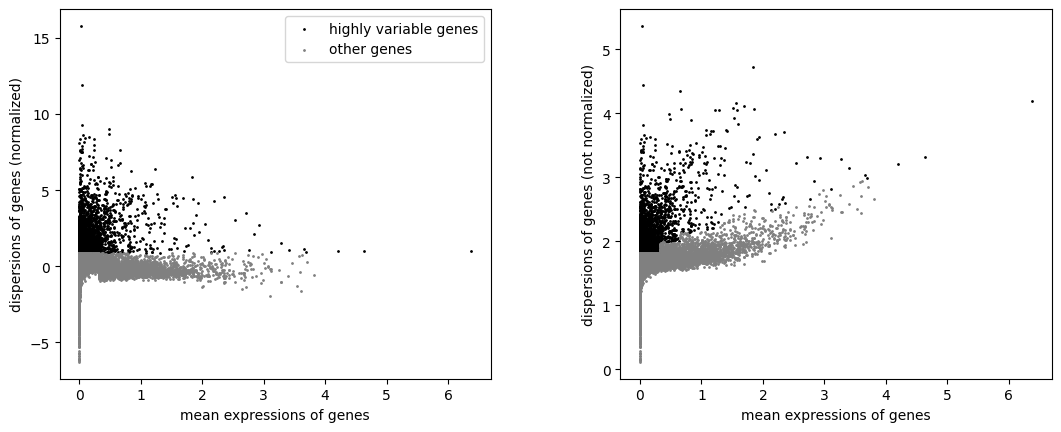

In [24]:
sc.pl.highly_variable_genes(adata)

In [25]:
adata_hvg = adata[:, adata.var["highly_variable"]] # creating a view of adata WHERE WE ONLY HAVE THE HVGs

In [26]:
sc.pp.regress_out(adata_hvg, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo']) ## regress out any differences due to processing or sample quality/technical artifact

/var/folders/9x/rm_064gx7k5bl4rpmwmghsv40000gn/T/ipykernel_29443/3527806728.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.regress_out(adata_hvg, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo']) ## regress out any differences due to processing or sample quality/technical artifact


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:673: RuntimeWarning: divide by zero encountered in matmul
  coeff = inv_gram_matrix @ (regressor.T @ data)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:673: RuntimeWarning: overflow encountered in matmul
  coeff = inv_gram_matrix @ (regressor.T @ data)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:673: RuntimeWarning: invalid value encountered in matmul
  coeff = inv_gram_matrix @ (regressor.T @ data)


In [27]:
sc.pp.scale(adata_hvg, max_value=10)

In [28]:
sc.tl.pca(adata_hvg, svd_solver='arpack')

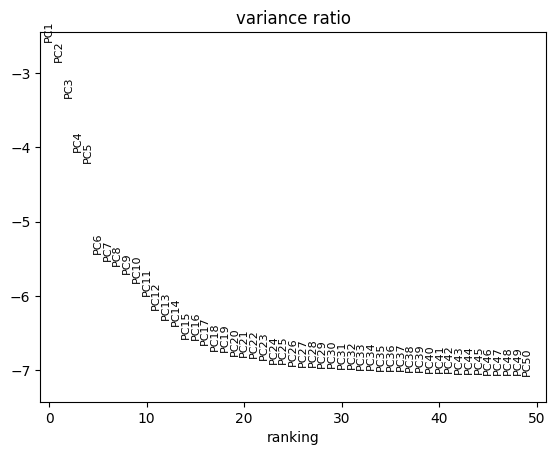

In [29]:
sc.pl.pca_variance_ratio(adata_hvg, log=True, n_pcs = 50)

In [30]:
## Since elbow is around 23, will just use 25 pcs
sc.pp.neighbors(adata_hvg, n_pcs=25)

In [31]:
adata_hvg.obsp['connectivities'] # this is a neighborhood matrice

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 429834 stored elements and shape (19405, 19405)>

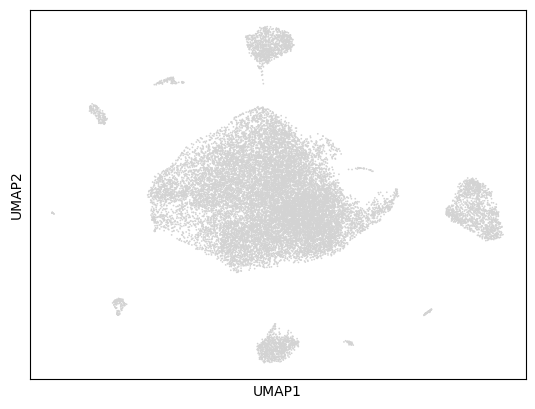

In [32]:
sc.tl.umap(adata_hvg)
sc.pl.umap(adata_hvg)

In [33]:
sc.tl.leiden(adata_hvg, resolution = 0.7) # starting with 0.7

/var/folders/9x/rm_064gx7k5bl4rpmwmghsv40000gn/T/ipykernel_29443/2717470044.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_hvg, resolution = 0.7) # starting with 0.7


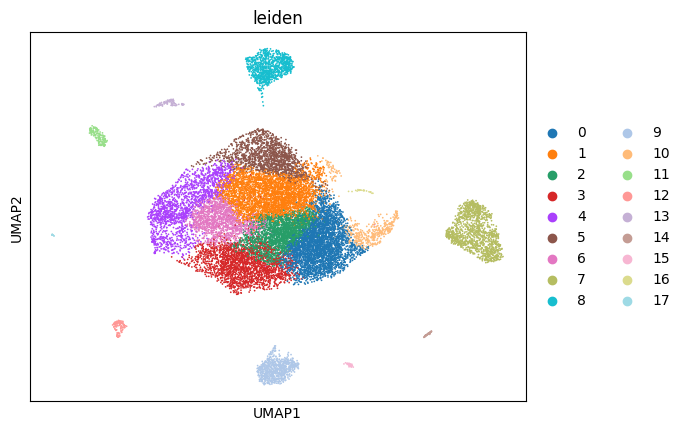

In [34]:
sc.pl.umap(adata_hvg, color=['leiden'])

## Now find markers/label cell types

In [35]:
sc.tl.rank_genes_groups(adata_hvg, 'leiden')

In [50]:
#sc.pl.rank_genes_groups(adata, n_genes = 20, sharey=False)

In [36]:
markers = sc.get.rank_genes_groups_df(adata_hvg, None)
markers = markers[(markers.pvals_adj < 0.05) & (markers.logfoldchanges > .5)]
## only keeping genes with a pval_adj os less than 0.05 and log2fc > .5

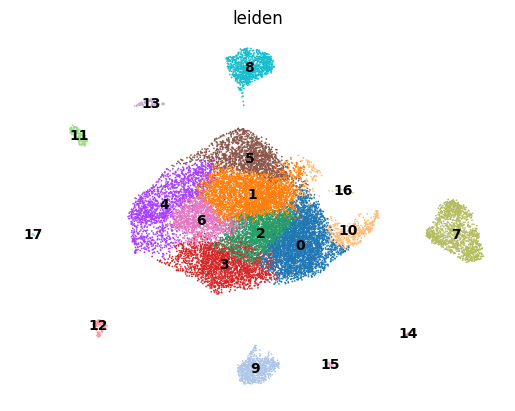

In [37]:
sc.pl.umap(adata_hvg, color = ['leiden'], frameon = False, legend_loc = "on data")

In [38]:
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]
adata.obs["leiden"] = adata_hvg.obs["leiden"]


## Now lets bring in the trinarizer and the auto-annotator

In [40]:
adata.write("STH_clustered.h5ad", compression="gzip")


In [7]:
from scanpy_trinarizer import build_trinarization_matrix
from scanpy_auto_annotator import load_rules, auto_annotate_results, add_annotations_to_adata
rules = load_rules("/Users/saatvikviniak/Desktop/Lab work/sc-RNA atlas/auto-annotation-ah/Human_adult")



In [9]:
adata_hvg

NameError: name 'adata_hvg' is not defined

In [ ]:
# Build trinarization calls from the raw  counts
results = build_trinarization_matrix(adata, cluster_key="leiden", count_layer="raw_counts", gene_key = "Gene") # replace if your raw counts are in another layer  
## need to fix the trinarization code because its absolutely racketed with errors; also add a progress bar



In [ ]:
# 

k: 7 n: 3458 frac: 0.0020242914979757085


In [ ]:

# Now it auto-annotates each cluster
annotations = auto_annotate_results(results, rules)




In [47]:
annotations

{'0': [],
 '1': [],
 '10': [],
 '11': [],
 '12': [],
 '13': [],
 '14': [],
 '15': [],
 '16': [],
 '17': [],
 '2': [],
 '3': [],
 '4': [],
 '5': [],
 '6': [],
 '7': [],
 '8': [],
 '9': []}

In [ ]:
## now this add the annotations back to the adata df
adata = add_annotations_to_adata(adata, annotations, cluster_key="leiden", obs_key="auto_annotation")

In [92]:
print(adata.layers.keys())
print(adata.layers["raw_counts"].shape)
print(adata.X.shape)

print(adata.var_names[:10])
print(adata.var["feature_name"].head(10))

cluster = "0"
mask = adata.obs["leiden"] == cluster
mat = adata.layers["raw_counts"][mask]

# fraction of nonzero counts for a few known markers
test_genes = ["MBP", "PLP1", "AQP4", "GAD1", "GAD2", "SLC17A7", "PDGFRA", "CLDN5"]
for g in test_genes:
    if g in adata.var_names:
        idx = adata.var_names.get_loc(g)
        frac = np.asarray((mat[:, idx] > 0).mean()).item()
        print("var_names", g, frac)
    elif "feature_name" in adata.var.columns and g in adata.var["feature_name"].values:
        idx = np.where(adata.var["feature_name"].values == g)[0][0]
        frac = np.asarray((mat[:, idx] > 0).mean()).item()
        print("feature_name", g, frac)
    else:
        print(g, "not found")


KeysView(Layers with keys: raw_counts)
(19405, 3000)
(19405, 3000)
Index(['ENSG00000197943', 'ENSG00000115232', 'ENSG00000143119',
       'ENSG00000196126', 'ENSG00000141293', 'ENSG00000168685',
       'ENSG00000172673', 'ENSG00000255733', 'ENSG00000271503',
       'ENSG00000160654'],
      dtype='object')
ENSG00000197943       PLCG2
ENSG00000115232       ITGA4
ENSG00000143119        CD53
ENSG00000196126    HLA-DRB1
ENSG00000141293       SKAP1
ENSG00000168685        IL7R
ENSG00000172673      THEMIS
ENSG00000255733    IFNG-AS1
ENSG00000271503        CCL5
ENSG00000160654        CD3G
Name: feature_name, dtype: category
Categories (2999, object): ['A1CF', 'A2M', 'A2ML1-AS1', 'ABCA10', ..., 'ZSCAN31', 'ZSCAN5A-AS1', 'ZSCAN9', 'ZSWIM2']


AttributeError: 'Series' object has no attribute 'nonzero'